# 📊 구독 유지 필요성 예측 모델
본 노트북은 `mock_data.csv` 데이터를 기반으로 사용자가 현재 이용 중인 구독 서비스를 계속 유지할 필요가 있는지 예측하는 초기 기준 모델을 학습하는 코드입니다.

- `0`: 해지 후보, 유지 필요성이 낮은 구독
- `1`: 유지 후보, 계속 사용할 가능성이 높은 구독

현재 데이터는 `10,000`건의 합성 데이터이며, `Logistic Regression`을 기준 모델로 사용합니다.

> 참고: 이 노트북의 코드와 설명은 `10,000`건 데이터 기준으로 수정되었습니다. 저장된 출력 셀은 이전 실행 결과가 남아 있을 수 있으므로, 최신 결과를 보려면 노트북을 한 번 다시 실행하면 됩니다.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

DATA_PATH = Path("mock_data.csv")
TEST_SIZE = 0.2
RANDOM_STATE = 42
NEGATIVE_LABEL = 0

## 1. 데이터 로드 (Load Data)
사전에 생성된 `mock_data.csv` 파일(10,000건)을 불러옵니다.

In [9]:
df = pd.read_csv(DATA_PATH)

print(f"데이터 파일: {DATA_PATH}")
print(f"데이터 크기: {df.shape}")
print("\n[타깃 분포 - 0: 해지 후보, 1: 유지 후보]")
print(df["Target"].value_counts().sort_index())

display(df.head())

데이터 파일: mock_data.csv
데이터 크기: (10000, 6)

[타깃 분포 - 0: 해지 후보, 1: 유지 후보]
Target
0    2058
1    7942
Name: count, dtype: int64


,Monthly_Fee,Access_Days,Usage_Time,Content_Count,Customer_Inquiry,Target
0,12266,11,859,17,2,1
1,13150,26,1007,15,0,1
2,13918,13,615,38,0,1
3,13153,21,830,42,0,1
4,9108,18,986,30,1,1


## 2. 파생 변수 생성
- **Inquiry_Rate (문의율)** = Customer_Inquiry / (Access_Days + 1)
- **Value_Score (가성비 점수)** = Usage_Time / Monthly_Fee

In [10]:
df["Inquiry_Rate"] = df["Customer_Inquiry"] / (df["Access_Days"] + 1)
df["Value_Score"] = df["Usage_Time"] / df["Monthly_Fee"]

print("파생 변수 추가 후 데이터 크기:", df.shape)
display(df.head())

파생 변수 추가 후 데이터 크기: (10000, 8)


,Monthly_Fee,Access_Days,Usage_Time,Content_Count,Customer_Inquiry,Target,Inquiry_Rate,Value_Score
0,12266,11,859,17,2,1,0.166667,0.070031
1,13150,26,1007,15,0,1,0.000000,0.076578
2,13918,13,615,38,0,1,0.000000,0.044187
3,13153,21,830,42,0,1,0.000000,0.063103
4,9108,18,986,30,1,1,0.052632,0.108256


## 3. 전처리 및 데이터 분할
`Target`을 제외한 변수를 입력값으로 사용하고, 학습 데이터와 테스트 데이터를 `8:2`로 분리합니다. 이후 `StandardScaler`로 수치형 변수의 스케일을 맞춥니다.

In [11]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("학습 데이터 크기:", X_train.shape, y_train.shape)
print("테스트 데이터 크기:", X_test.shape, y_test.shape)

학습 데이터 크기: (8000, 7) (8000,)
테스트 데이터 크기: (2000, 7) (2000,)


## 4. 로지스틱 회귀 모델 학습

In [12]:
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("학습 완료")
print("모델 계수 개수:", len(model.coef_[0]))

학습 완료
모델 계수 개수: 7


## 5. 상세 모델 성능 평가
단순 정확도만 보지 않고, 클래스 `0`인 해지 후보를 얼마나 잘 찾아내는지에 초점을 맞춰 성능을 평가합니다. 사용자 관점에서는 불필요한 구독을 놓치지 않는 `Recall`이 특히 중요합니다.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=NEGATIVE_LABEL)
recall = recall_score(y_test, y_pred, pos_label=NEGATIVE_LABEL)
f1 = f1_score(y_test, y_pred, pos_label=NEGATIVE_LABEL)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("=== 로지스틱 회귀 평가 결과 ===")
print(f"정확도 (Accuracy)                : {accuracy:.4f}")
print(f"정밀도 (Precision, 클래스 0 기준): {precision:.4f}")
print(f"재현율 (Recall, 클래스 0 기준)   : {recall:.4f}")
print(f"F1-점수 (클래스 0 기준)          : {f1:.4f}")
print(f"ROC-AUC 점수                    : {roc_auc:.4f}")
print("\n[혼동 행렬]")
print(cm)
print("\n[분류 보고서]")
print(classification_report(y_test, y_pred, digits=4))

=== 로지스틱 회귀 평가 결과 ===
정확도 (Accuracy)                : 0.9955
정밀도 (Precision, 클래스 0 기준): 0.9951
재현율 (Recall, 클래스 0 기준)   : 0.9830
F1-점수 (클래스 0 기준)          : 0.9890
ROC-AUC 점수                    : 0.9997

[혼동 행렬]
[[ 405    7]
 [   2 1586]]

[분류 보고서]
              precision    recall  f1-score   support

           0     0.9951    0.9830    0.9890       412
           1     0.9956    0.9987    0.9972      1588

    accuracy                         0.9955      2000
   macro avg     0.9953    0.9909    0.9931      2000
weighted avg     0.9955    0.9955    0.9955      2000



## 6. 혼동 행렬 시각화
모델이 해지 후보와 유지 후보를 어떻게 분류했는지 시각적으로 확인합니다.

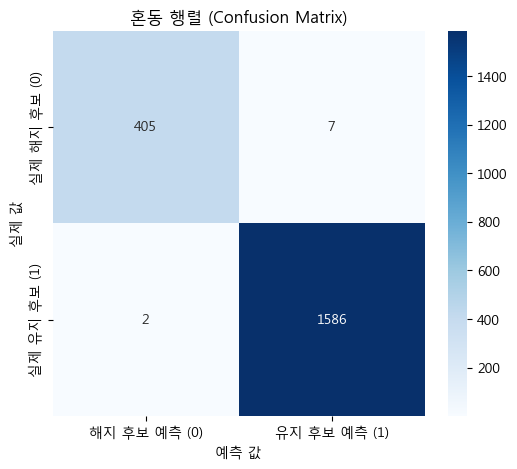

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["해지 후보 예측 (0)", "유지 후보 예측 (1)"],
    yticklabels=["실제 해지 후보 (0)", "실제 유지 후보 (1)"],
)
plt.title("혼동 행렬 (Confusion Matrix)")
plt.ylabel("실제 값")
plt.xlabel("예측 값")
plt.show()